In [31]:
import sys

sys.path.append('../src/')
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import pysindy as ps
from libselection.utils import *
from libselection import *
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl

# Full order model visualization

In [32]:
visc_data = np.load('../Data/16_roll7vtk_Re1_Wi3.5_beta0.9.npz', allow_pickle=True)['fields'].item()
print(visc_data.keys())

dict_keys(['x', 'y', 'vel-u', 'vel-v', 'trace_A', 'Bxx', 'Bxy', 'Byy'])


(128, 128, 7519)


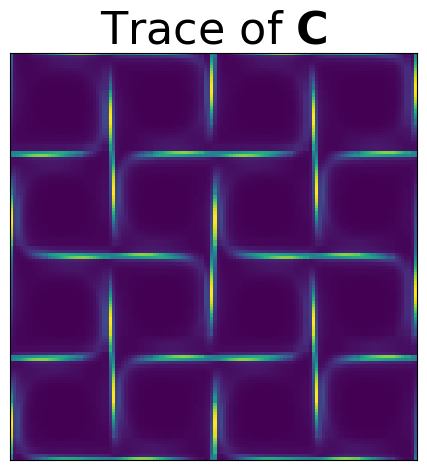

In [33]:
Bxx = visc_data['Bxx']
Bxy = visc_data['Bxy']
Byy = visc_data['Byy']
Tra = visc_data['trace_A']
print(Tra.shape)
plt.Figure(figsize=(16,17))
plt.imshow(Tra[...,3500])
plt.xticks([])
plt.yticks([])

plt.title('Trace of $\\mathbf{C}$', fontsize=32)
ax = plt.gca()
ax.set_aspect('equal')
# plt.colorbar(ax.images[0], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig('Figs/visc_example.png', dpi=1200)


# Data Generation

In [34]:
Avh = np.load("../Data/16_roll_Wi_3.5.npy", allow_pickle=True)
t = Avh[:, 0]
Avh = Avh[:,1:]

active_idx = [0, 1]  # Dynamically active modes
# first two POD modes
r = 2
tfrac = 0.8  # Proportion of the data to train on
M = len(t)
M_train = int(len(t) * tfrac)
t_train = t[:M_train]
t_test = t[M_train:]

pod_names = ["a_{}".format(1+i) for i in (active_idx)]
# pod_names = ['x', 'y']

# Normalize the trajectories for simplicity
normalization = sum(np.amax(abs(Avh), axis=0)[active_idx])
x = np.zeros((Avh.shape[0], r))
    
x[:, 0] = Avh[:, 0] / normalization
x[:, 1] = Avh[:, 1] / normalization


x_train = x[:M_train, :]
x0_train = x[0, :]
x_test = x[M_train:, :]
x0_test = x[M_train, :]

library_gen = ps.PolynomialLibrary(degree=4) # + ps.FourierLibrary(n_frequencies=2)
D = np.array(library_gen.fit_transform(x_train))
name_tag = np.array(library_gen.get_feature_names(pod_names))
dt = 1.0
x_dot = non_uniform_diff(x_train, t_train)


_, No_D = D.shape
print('No_D5=',len(D[0,:]),'rank=',np.linalg.matrix_rank(D), D[0,:].shape == np.linalg.matrix_rank(D))
print('--------------------')
print('Case:',name_tag)
print('No_D5=',len(D[0,:]),'rank=',np.linalg.matrix_rank(D), D[0,:].shape == np.linalg.matrix_rank(D))

No_D5= 15 rank= 15 [ True]
--------------------
Case: ['1' 'a_1' 'a_2' 'a_1^2' 'a_1 a_2' 'a_2^2' 'a_1^3' 'a_1^2 a_2' 'a_1 a_2^2'
 'a_2^3' 'a_1^4' 'a_1^3 a_2' 'a_1^2 a_2^2' 'a_1 a_2^3' 'a_2^4']
No_D5= 15 rank= 15 [ True]


# Compute Score

52.38095238095238 52.38095238095238
(14, 15)


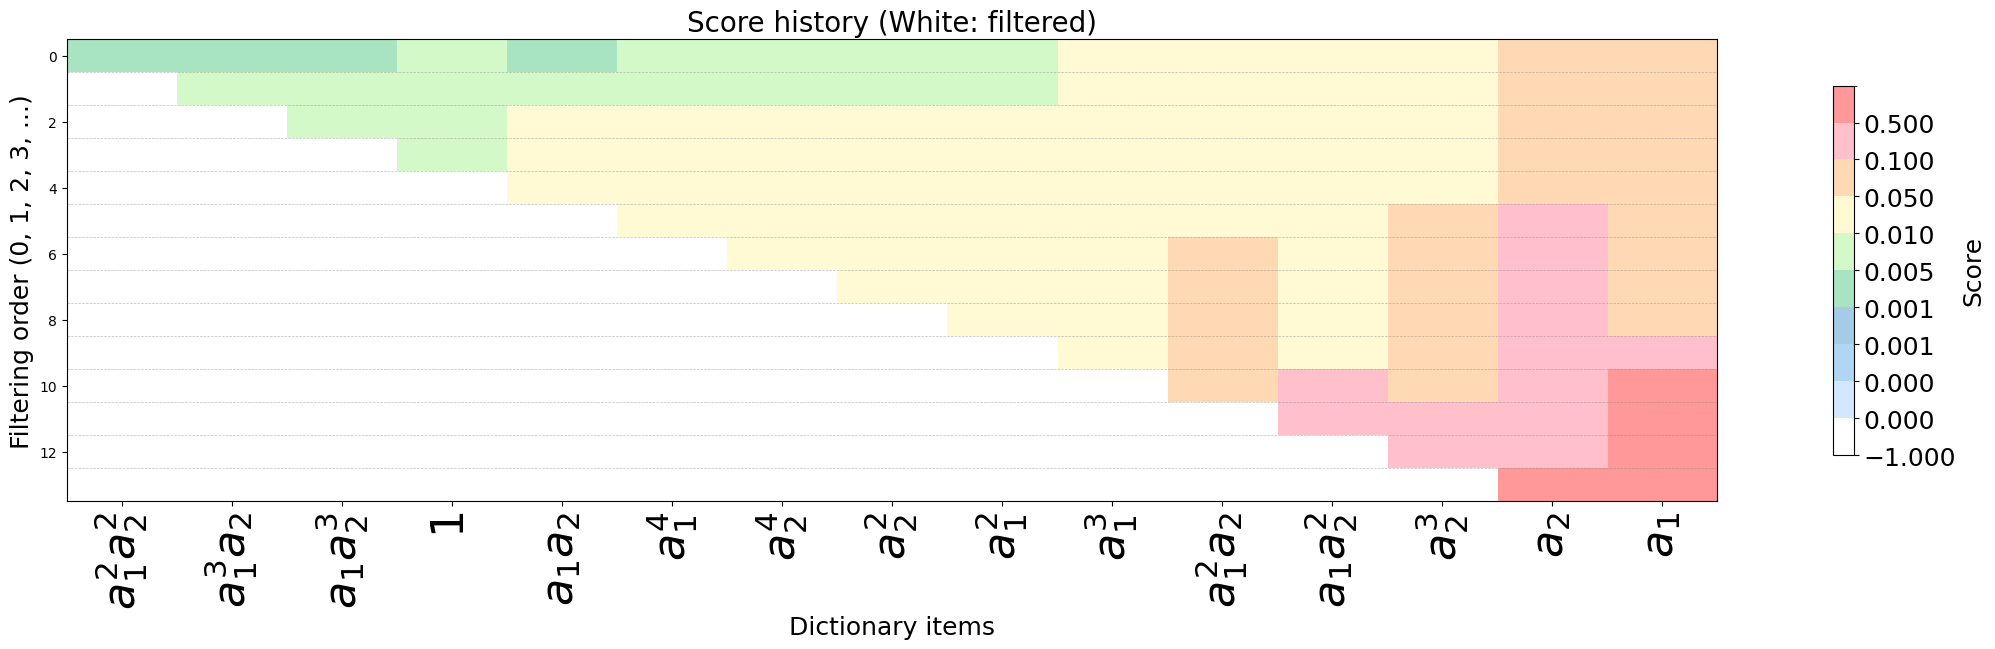

In [36]:
# Weak form support size computation
x_var =x_train
# Compute the Fourier transform of Y
fft_values = np.fft.fft(x_var - x_var.mean(axis=0), axis=0)
# Compute the magnitude of the Fourier modes
magnitudes = np.abs(fft_values)
# Find the maximum magnitude for each variable

max_magnitude_indices = np.argmax(magnitudes) + 1

# Compute L for each variable
M = x_var.shape[0]  # Number of samples
sps = 0.5 * (M / max_magnitude_indices) 
L = sps * dt
print(sps, L)
# Exhaustive filtering
V, dV = generate_overlapping_test_function_matrices(t_train,2*No_D, l=L, p=17)
G = V@D
b = -dV@x_train

best_comb, removed_order, history_values = iter_scores( G, b, n_terms=1, stepwise=True, backwards=True, stepsize=1)
plot_filtering_history_sorted(removed_order, history_values, name_tag, save_path=None, save_eps=True, diff_score=False, backwards = True,print_inside=False)

In [37]:
# SINDy identification
eps = 1e-4
C = SINDy(b,G,eps =eps)
print('SINDy identification before filtering:')
print_model(C, name_tag)
print()
# SINDy identification after filtering
G_filtered = G[:, removed_order[-6:]]
C_filtered = SINDy(b,G_filtered,eps =eps)
print('SINDy identification after filtering:')
print_model(C_filtered, name_tag[removed_order[-6:]])

SINDy identification before filtering:
x0' = -0.000 1 + 0.007 a_1 + 0.028 a_2 + 0.015 a_1^2 + 0.005 a_1 a_2 + -0.009 a_2^2 + -0.045 a_1^3 + -0.028 a_1^2 a_2 + 0.022 a_1 a_2^2 + 0.015 a_2^3 + -0.057 a_1^4 + -0.011 a_1^3 a_2 + -0.019 a_1^2 a_2^2 + -0.020 a_1 a_2^3 + 0.034 a_2^4 
x1' = -0.030 a_1 + 0.006 a_2 + -0.001 a_1^2 + -0.009 a_1 a_2 + 0.003 a_2^2 + -0.006 a_1^3 + 0.026 a_1^2 a_2 + 0.036 a_1 a_2^2 + -0.041 a_2^3 + 0.005 a_1^4 + 0.033 a_1^3 a_2 + -0.011 a_1^2 a_2^2 + 0.032 a_1 a_2^3 + -0.009 a_2^4 

SINDy identification after filtering:
x0' = -0.042 a_1^3 + -0.021 a_1^2 a_2 + 0.026 a_1 a_2^2 + 0.023 a_2^3 + 0.026 a_2 + 0.006 a_1 
x1' = -0.011 a_1^3 + 0.024 a_1^2 a_2 + 0.032 a_1 a_2^2 + -0.045 a_2^3 + 0.007 a_2 + -0.029 a_1 


In [38]:
n_vars = len(pod_names)

history_value_removed = np.zeros((n_vars,No_D))
filtering_order = np.zeros((n_vars,No_D), dtype=int)

history_value_pareto = np.zeros((n_vars,No_D))
filtering_order_pareto = np.zeros((n_vars,No_D), dtype=int)

history_value_cv = np.zeros((n_vars,No_D))
filtering_order_cv = np.zeros((n_vars,No_D), dtype=int)


for var in range(n_vars):
    _, history_index, history_value = iter_scores( G, b[:,var:var+1], n_terms=1, stepwise=True, backwards=True, stepsize=1)
    history_value_pareto[var,:], filtering_order_pareto[var,:] = get_pareto_scores(G, b[:,var:var+1])
    history_value_cv[var,:], filtering_order_cv[var,:] = get_cv_scores(G, b[:,var:var+1])

    # Determine the filtering order
    filtering_order[var,:] = history_index
    for i in range(No_D - 1):
        history_value_removed[var,i] = history_value[i, filtering_order[var,i]]
    history_value_removed[var,-1] = history_value[-1, filtering_order[var, -1]]

C:\Users\fabio\AppData\Local\Temp\ipykernel_44056\720434042.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


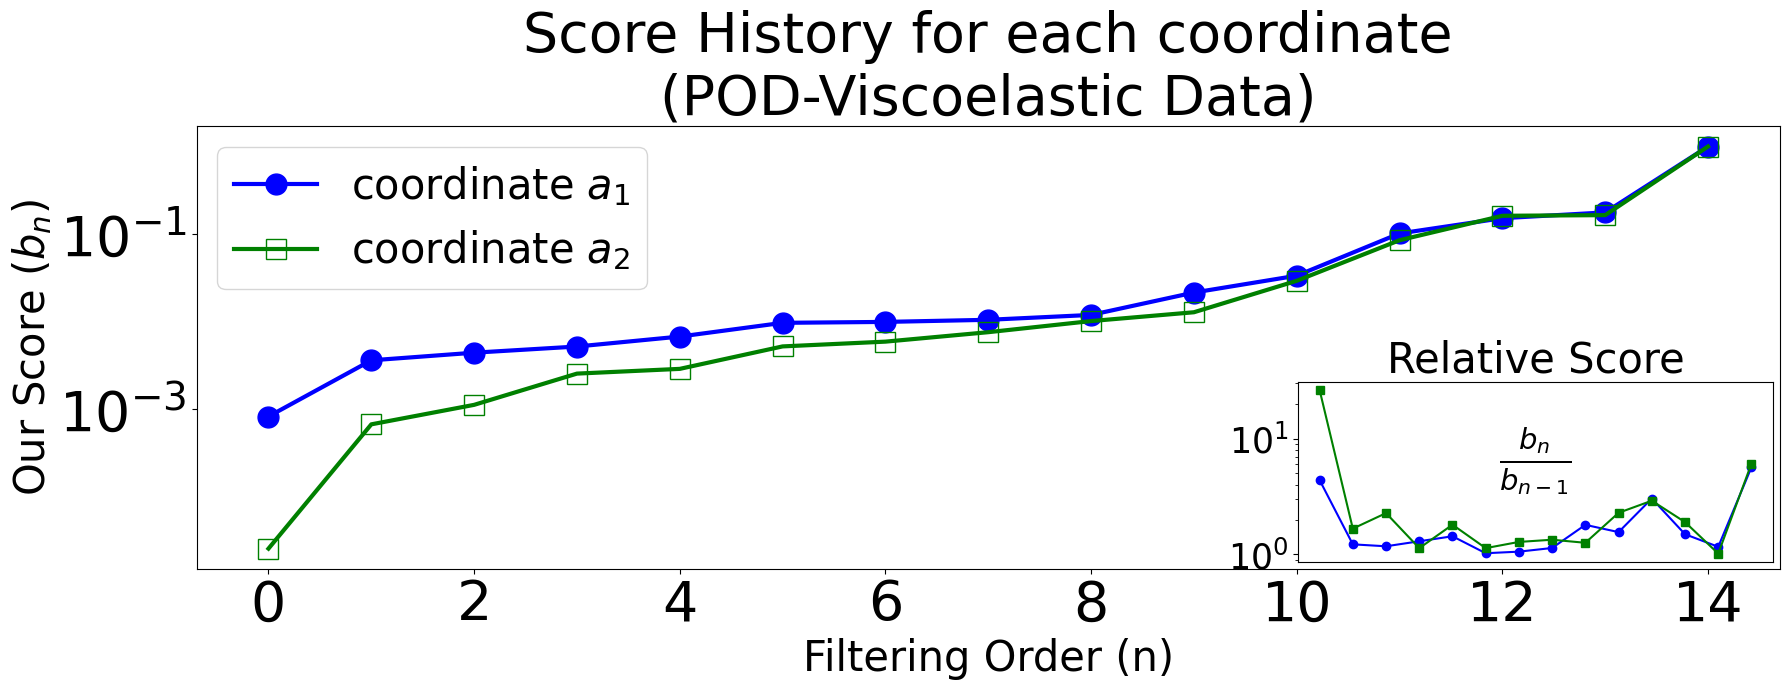

In [41]:
#create figure
line_style = ['dashed', 'dotted']
coords = ['$a_1$', '$a_2$']
markers = ['o', 's', 'v']
colors = ['b', 'g', 'm']
sizes = [4,8]
fs = 30
fig, ax = plt.subplots(1,1,figsize=(18, 7), sharex=True)

ax.set_title('Score History for each coordinate\n(POD-Viscoelastic Data)', fontsize=40)

filt_order = []
filt_order.append(filtering_order)

rel_scores = []
rel_scores.append(history_value_removed[:,1:] / history_value_removed[:,:-1])

inset_axs = []
inset_axs.append(inset_axes(ax,
                    width="30%", # width = 40% of parent_bbox
                    height=1.8, # height : 1 inch
                    loc='lower right'))



for idx in range(history_value_removed.shape[0]):
    ax.plot(history_value_removed[idx], color=colors[idx], marker=markers[idx], label=f'coordinate {coords[idx]}', lw = 3, markersize=15,markerfacecolor='none' if idx==1 else None)

    for ia, rs, fo in zip(inset_axs, rel_scores, filt_order):
        ia.plot(rs[idx], color=colors[idx], marker=markers[idx], label=f'coordinate {coords[idx]}')
       



ax.set_yscale('log')
ax.set_ylabel('Our Score ($b_n$)', fontsize=fs)
ax.tick_params(axis='both', which='major', labelsize=40)

rel_scores_labels = ['$\\frac{b_n}{b_{n-1}}$', '$\\frac{c_n}{c_{n-1}}$', '$\\frac{\\delta[n]}{\\delta[n-1]}$']
for ia, label in zip(inset_axs, rel_scores_labels):

    ia.set_yscale('log')
    ia.set_xticks([])
    ia.annotate(label, xy=(0.5, 0.5), xycoords='axes fraction', ha='center', fontsize=fs)
    ia.tick_params(axis='both', which='major', labelsize=25)
inset_axs[0].set_title('Relative Score', fontsize=30)
ax.legend(fontsize=fs)
ax.set_xlabel('Filtering Order (n)', fontsize=fs)

plt.tight_layout()
plt.savefig('Figs/score_compare_each_coordinate_POD.pdf', format='pdf')


C:\Users\fabio\AppData\Local\Temp\ipykernel_44056\1372588682.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


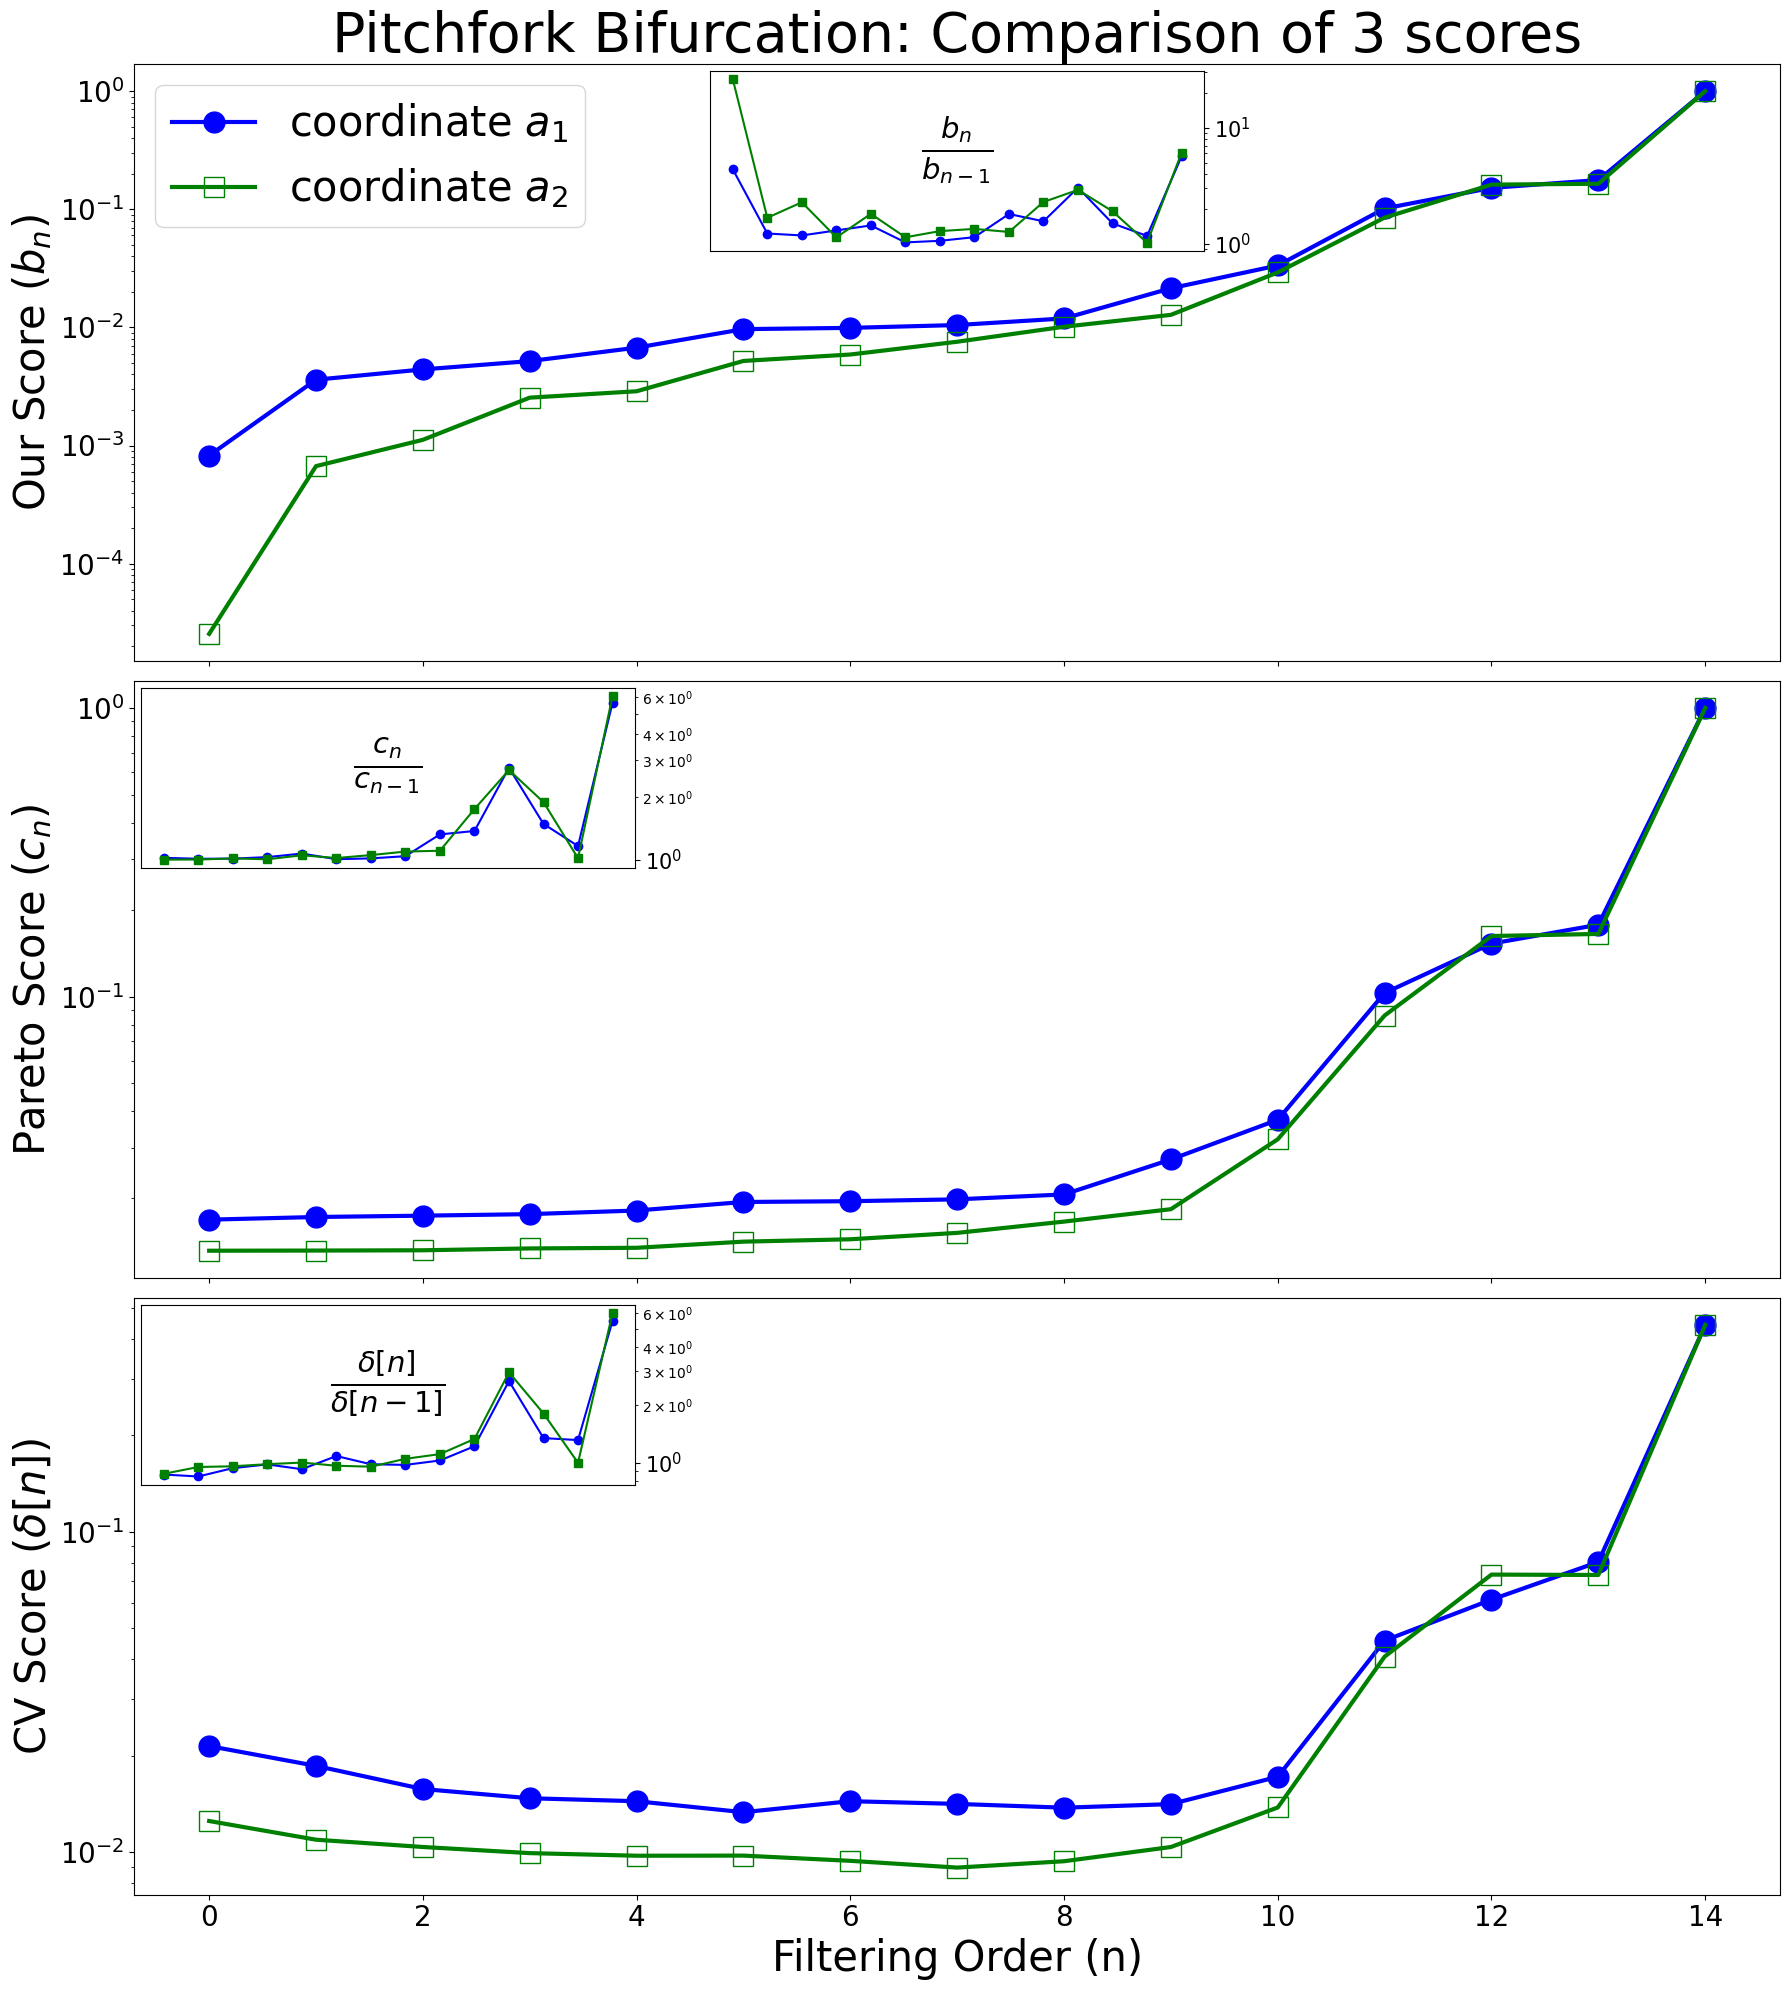

In [40]:
#create figure
line_style = ['dashed', 'dotted']
coords = ['$a_1$', '$a_2$']
markers = ['o', 's', 'v']
colors = ['b', 'g', 'm']
sizes = [4,8]
fs = 30
fig, ax = plt.subplots(3,1,figsize=(18, 20), sharex=True)

ax[0].set_title('Pitchfork Bifurcation: Comparison of 3 scores', fontsize=40)
n_terms = [2,1]  # Manually set based on previous jumps detected
n_terms = [No_D - n for n in n_terms]

filt_order = []
filt_order.append(filtering_order)
filt_order.append(filtering_order_pareto)
filt_order.append(filtering_order_cv)

rel_scores = []
rel_scores.append(history_value_removed[:,1:] / history_value_removed[:,:-1])
rel_scores.append(history_value_pareto[:,1:] / history_value_pareto[:,:-1])
rel_scores.append(history_value_cv[:,1:] / history_value_cv[:,:-1])

inset_axs = []
inset_axs.append(inset_axes(ax[0],
                    width="30%", # width = 40% of parent_bbox
                    height=1.8, # height : 1 inch
                    loc='upper center'))
inset_axs.append(inset_axes(ax[1],
                    width="30%", # width = 40% of parent_bbox
                    height=1.8, # height : 1 inch
                    loc='upper left'))
inset_axs.append(inset_axes(ax[2],
                    width="30%", # width = 40% of parent_bbox
                    height=1.8, # height : 1 inch
                    loc='upper left'))



for idx in range(history_value_removed.shape[0]):
    ax[0].plot(history_value_removed[idx], color=colors[idx], marker=markers[idx], label=f'coordinate {coords[idx]}', lw = 3, markersize=15,markerfacecolor='none' if idx==1 else None)
    ax[1].plot(history_value_pareto[idx], color=colors[idx], marker=markers[idx], label=f'coordinate {coords[idx]}', lw = 3, markersize=15,markerfacecolor='none' if idx==1 else None)
    ax[2].plot(history_value_cv[idx], color=colors[idx], marker=markers[idx], label=f'coordinate {coords[idx]}', lw = 3, markersize=15,markerfacecolor='none' if idx==1 else None)

    for ia, rs, fo in zip(inset_axs, rel_scores, filt_order):
        ia.plot(rs[idx], color=colors[idx], marker=markers[idx], label=f'coordinate {coords[idx]}')
       

labels = ['Our Score ($b_n$)', 'Pareto Score ($c_n$)', 'CV Score ($\\delta[n]$)']

for i, a in enumerate(ax):
    a.set_yscale('log')
    a.set_ylabel(labels[i], fontsize=fs)
    a.tick_params(axis='both', which='major', labelsize=20)

rel_scores_labels = ['$\\frac{b_n}{b_{n-1}}$', '$\\frac{c_n}{c_{n-1}}$', '$\\frac{\\delta[n]}{\\delta[n-1]}$']
for ia, label in zip(inset_axs, rel_scores_labels):
    ia.yaxis.set_label_position("right")
    ia.yaxis.tick_right()
    ia.set_yscale('log')
    ia.set_xticks([])
    ia.annotate(label, xy=(0.5, 0.5), xycoords='axes fraction', ha='center', fontsize=fs)
    ia.tick_params(axis='both', which='major', labelsize=15)

ax[0].legend(fontsize=fs)
ax[2].set_xlabel('Filtering Order (n)', fontsize=fs)

plt.tight_layout()
# plt.savefig('Figs/compare_three_scores_pitchfork.pdf', format='pdf')
